# Module 2 — The Noise Paradox

**Research Question**: Does environmental noise destroy or promote cooperation in LLM agents?

**Key Finding**: Noise *increases* cooperation — both mechanically (flipping defections to cooperation) and behaviorally (LLMs strategically adapt by becoming more cooperative).

**Outputs**: Figure 2a (intended vs actual), Figure 2b (decomposition), Figure 2c (welfare analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import ast
import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality settings ──
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MODEL_COLORS = {
    'GPT-oss-20B': '#E69F00',
    'Mistral-7B': '#56B4E9',
    'Qwen2.5-32B': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
NOISE_LABELS = {0.0: '0%', 0.05: '5%', 0.2: '20%'}
PERSONALITY_MAP = {
    'cooperative': 'Cooperative', 'selfish': 'Selfish',
    'coopératif': 'Cooperative', 'égoïste': 'Selfish',
    'متعاون': 'Cooperative', 'أناني': 'Selfish',
    '合作型的': 'Cooperative', '自私型的': 'Selfish',
    'một người hợp tác': 'Cooperative', 'một người ích kỷ': 'Selfish',
    'cooperativo': 'Cooperative', 'egoista': 'Selfish'
}
FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
# ── Load and preprocess ──
DATA_PATH = '../resources/results/Prisoner_dilemma_2player/consolidated_dataset.csv'
df = pd.read_csv(DATA_PATH)
df['personality'] = df['agent1_personality'].map(PERSONALITY_MAP)
df['model'] = df['agent1_llm'].map(MODEL_LABELS)

# Compute intended cooperation rate
df['intended_coop_rate'] = df['agent1_intended_strategies'].apply(
    lambda x: ast.literal_eval(x).count('OptionB') / 30
)
df['actual_coop_rate'] = df['agent1_cooperation_rate']

# Mechanical vs behavioral decomposition
# Mechanical effect = actual - intended (due to random flips)
# Behavioral effect = intended(noisy) - intended(no noise)
df['mechanical_effect'] = df['actual_coop_rate'] - df['intended_coop_rate']

print(f'Loaded {len(df)} games')

Loaded 2160 games


## 2.1 Figure 2a — Intended vs Actual Cooperation Rate

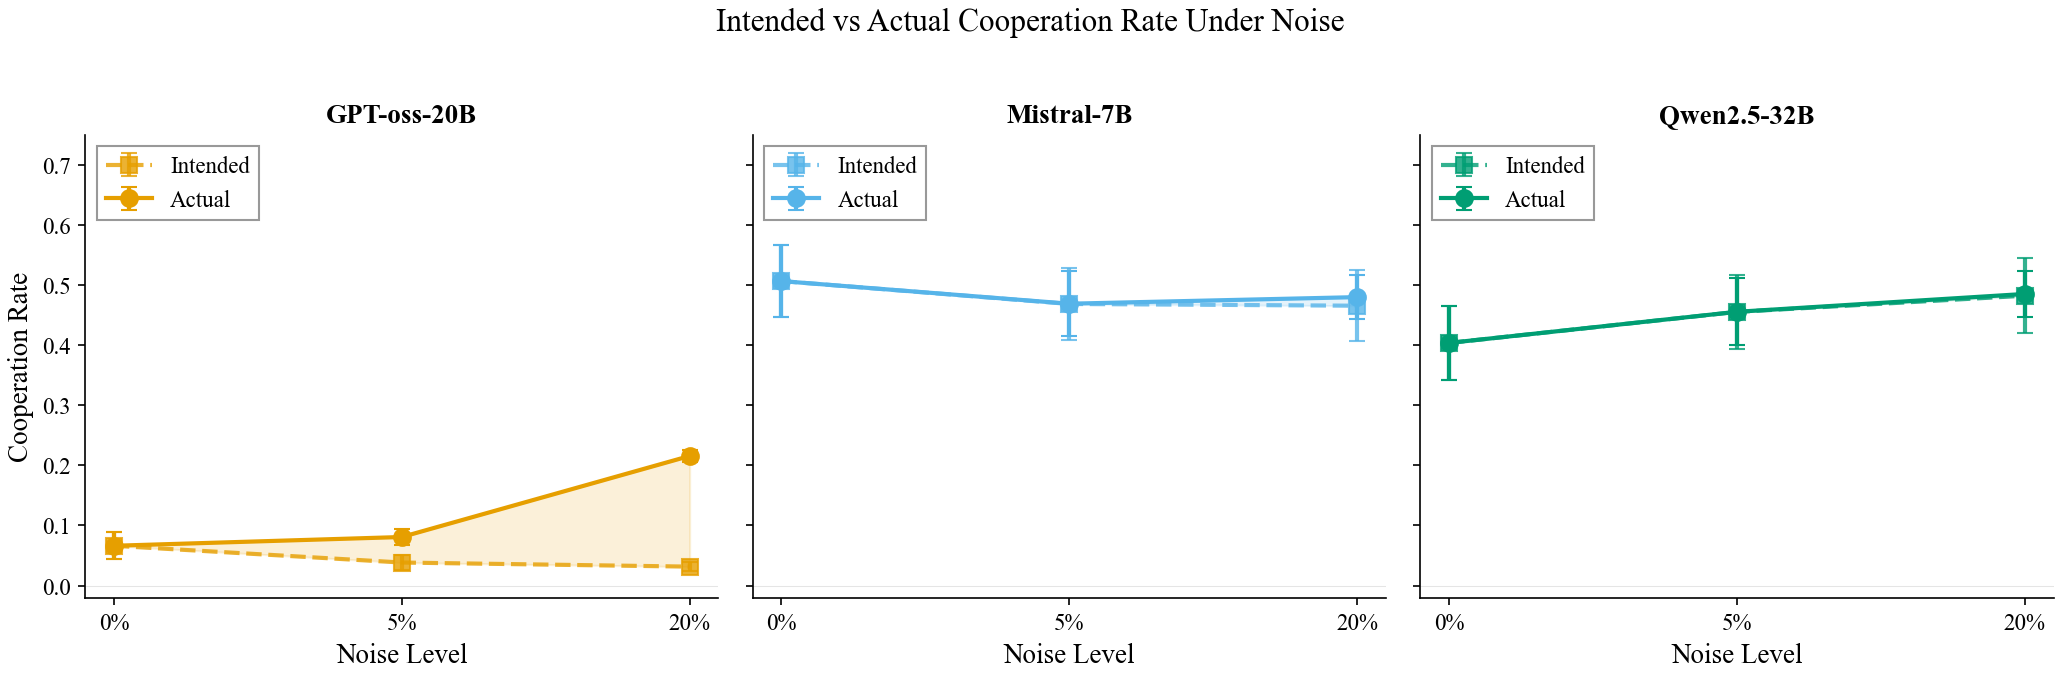

Saved: fig2a_intended_vs_actual.pdf/png


In [3]:
# ── Figure 2a: Intended vs Actual cooperation by noise level, per model ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
noise_levels = [0.0, 0.05, 0.2]
models_order = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']

for idx, model in enumerate(models_order):
    ax = axes[idx]
    sub = df[df['model'] == model]
    
    intended_means = [sub[sub['agent1_noise_rate'] == n]['intended_coop_rate'].mean() for n in noise_levels]
    intended_sems = [sub[sub['agent1_noise_rate'] == n]['intended_coop_rate'].sem() for n in noise_levels]
    actual_means = [sub[sub['agent1_noise_rate'] == n]['actual_coop_rate'].mean() for n in noise_levels]
    actual_sems = [sub[sub['agent1_noise_rate'] == n]['actual_coop_rate'].sem() for n in noise_levels]
    
    x = np.arange(len(noise_levels))
    ax.errorbar(x, intended_means, yerr=np.array(intended_sems)*1.96,
                marker='s', markersize=8, linewidth=2, capsize=4,
                color=MODEL_COLORS[model], linestyle='--', label='Intended', alpha=0.8)
    ax.errorbar(x, actual_means, yerr=np.array(actual_sems)*1.96,
                marker='o', markersize=8, linewidth=2, capsize=4,
                color=MODEL_COLORS[model], linestyle='-', label='Actual')
    
    # Shade the gap (mechanical effect)
    ax.fill_between(x, intended_means, actual_means, alpha=0.15, color=MODEL_COLORS[model])
    
    ax.set_xticks(x)
    ax.set_xticklabels([NOISE_LABELS[n] for n in noise_levels])
    ax.set_xlabel('Noise Level')
    ax.set_title(model, fontsize=13, fontweight='bold')
    ax.set_ylim(-0.02, 0.75)
    ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='gray')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.2, linewidth=0.5)

axes[0].set_ylabel('Cooperation Rate')
fig.suptitle('Intended vs Actual Cooperation Rate Under Noise', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig2a_intended_vs_actual.pdf')
fig.savefig(f'{FIGURE_DIR}fig2a_intended_vs_actual.png')
plt.show()
print('Saved: fig2a_intended_vs_actual.pdf/png')

## 2.2 Noise Effect Decomposition

In [4]:
# ── Decompose noise effect into mechanical + behavioral ──
# Behavioral = change in intended coop rate relative to no-noise baseline
# Mechanical = actual - intended (random flips)

decomp_rows = []
for model in models_order:
    baseline_intended = df[(df['model'] == model) & (df['agent1_noise_rate'] == 0.0)]['intended_coop_rate'].mean()
    
    for noise in noise_levels:
        sub = df[(df['model'] == model) & (df['agent1_noise_rate'] == noise)]
        intended = sub['intended_coop_rate'].mean()
        actual = sub['actual_coop_rate'].mean()
        
        behavioral = intended - baseline_intended  # strategic adaptation
        mechanical = actual - intended              # random flip effect
        total_change = actual - baseline_intended   # total vs baseline
        
        decomp_rows.append({
            'Model': model, 'Noise': NOISE_LABELS[noise],
            'Noise_val': noise,
            'Baseline_Intended': baseline_intended,
            'Intended': intended, 'Actual': actual,
            'Behavioral': behavioral, 'Mechanical': mechanical,
            'Total_Change': total_change
        })

decomp = pd.DataFrame(decomp_rows)
print(decomp[['Model', 'Noise', 'Baseline_Intended', 'Intended', 'Actual',
              'Behavioral', 'Mechanical', 'Total_Change']].to_string(index=False))

      Model Noise  Baseline_Intended  Intended   Actual  Behavioral    Mechanical  Total_Change
GPT-oss-20B    0%           0.066250  0.066250 0.066245    0.000000 -5.000000e-06 -5.000000e-06
GPT-oss-20B    5%           0.066250  0.038333 0.080830   -0.027917  4.249708e-02  1.458042e-02
GPT-oss-20B   20%           0.066250  0.031528 0.215697   -0.034722  1.841689e-01  1.494467e-01
 Mistral-7B    0%           0.506806  0.506806 0.506807    0.000000  1.527778e-06  1.527778e-06
 Mistral-7B    5%           0.506806  0.468750 0.469165   -0.038056  4.150000e-04 -3.764056e-02
 Mistral-7B   20%           0.506806  0.465833 0.480140   -0.040972  1.430625e-02 -2.666597e-02
Qwen2.5-32B    0%           0.403889  0.403889 0.403889    0.000000  2.777778e-07  2.777778e-07
Qwen2.5-32B    5%           0.403889  0.455556 0.455694    0.051667  1.386111e-04  5.180528e-02
Qwen2.5-32B   20%           0.403889  0.482500 0.485419    0.078611  2.919167e-03  8.153028e-02


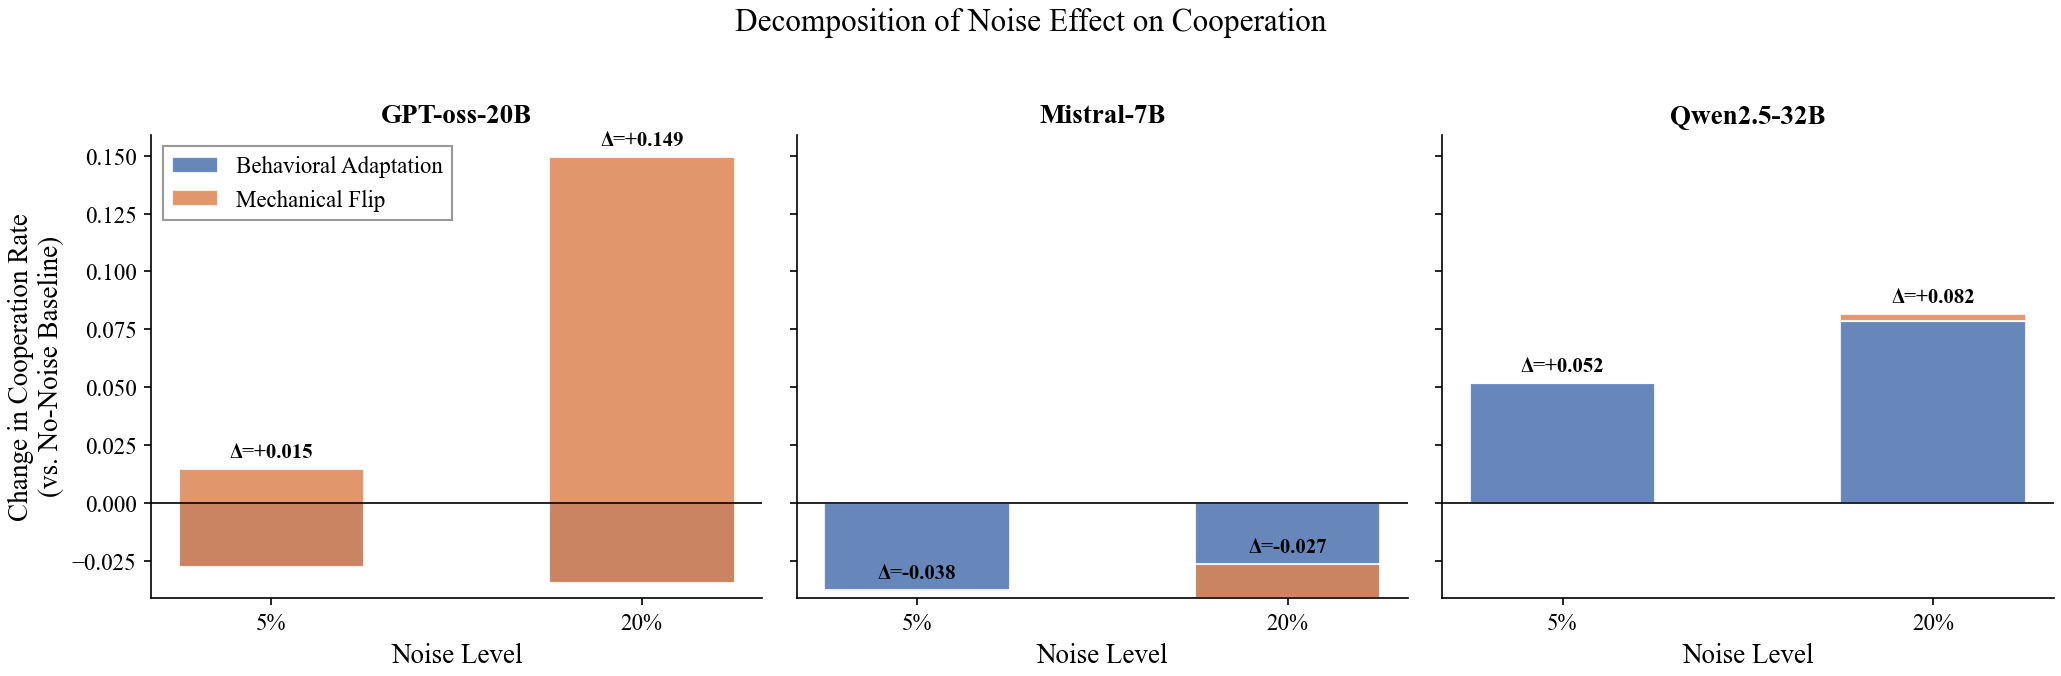

Saved: fig2b_noise_decomposition.pdf/png


In [5]:
# ── Figure 2b: Stacked bar — Noise effect decomposition ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, model in enumerate(models_order):
    ax = axes[idx]
    d = decomp[(decomp['Model'] == model) & (decomp['Noise_val'] > 0)]
    
    x = np.arange(len(d))
    width = 0.5
    
    # Behavioral effect (bottom)
    behavioral_vals = d['Behavioral'].values
    mechanical_vals = d['Mechanical'].values
    
    # Handle negative behavioral values
    beh_pos = np.maximum(behavioral_vals, 0)
    beh_neg = np.minimum(behavioral_vals, 0)
    
    bars1 = ax.bar(x, behavioral_vals, width, label='Behavioral Adaptation',
                   color='#4C72B0', alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x, mechanical_vals, width, bottom=behavioral_vals,
                   label='Mechanical Flip', color='#DD8452', alpha=0.85, edgecolor='white')
    
    # Total annotation
    for i, (b, m, t) in enumerate(zip(behavioral_vals, mechanical_vals, d['Total_Change'].values)):
        ax.annotate(f'Δ={t:+.3f}', (i, b + m + 0.005), ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(d['Noise'].values)
    ax.set_xlabel('Noise Level')
    ax.set_title(model, fontsize=13, fontweight='bold')
    ax.axhline(y=0, color='black', linewidth=0.8)
    if idx == 0:
        ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='gray')

axes[0].set_ylabel('Change in Cooperation Rate\n(vs. No-Noise Baseline)')
fig.suptitle('Decomposition of Noise Effect on Cooperation', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig2b_noise_decomposition.pdf')
fig.savefig(f'{FIGURE_DIR}fig2b_noise_decomposition.png')
plt.show()
print('Saved: fig2b_noise_decomposition.pdf/png')

## 2.3 Figure 2c — Welfare Analysis Under Noise

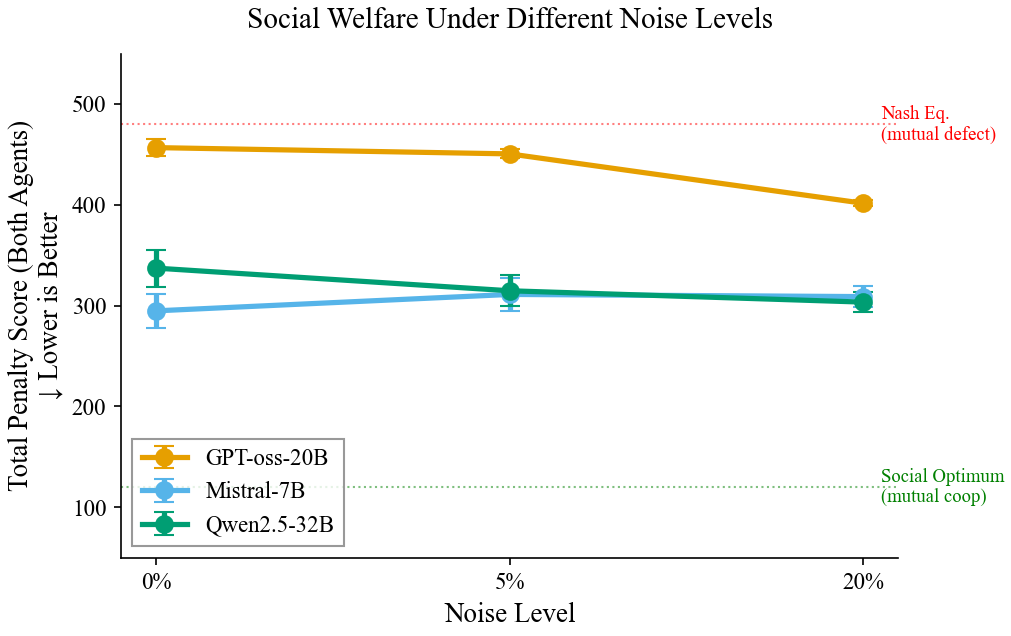

Saved: fig2c_welfare_noise.pdf/png


In [6]:
# ── Figure 2c: Total penalty score (welfare) by model × noise ──
df['social_welfare'] = df['agent1_total_score'] + df['agent2_total_score']

fig, ax = plt.subplots(figsize=(7, 4.5))

for model in models_order:
    sub = df[df['model'] == model]
    means = [sub[sub['agent1_noise_rate'] == n]['social_welfare'].mean() for n in noise_levels]
    sems = [sub[sub['agent1_noise_rate'] == n]['social_welfare'].sem() for n in noise_levels]
    
    ax.errorbar(
        [NOISE_LABELS[n] for n in noise_levels], means,
        yerr=np.array(sems) * 1.96,
        marker='o', markersize=8, linewidth=2.5, capsize=5,
        color=MODEL_COLORS[model], label=model
    )

# Reference lines
ax.axhline(y=120, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax.text(2.05, 120, 'Social Optimum\n(mutual coop)', fontsize=9, color='green', va='center')
ax.axhline(y=480, color='red', linestyle=':', alpha=0.5, linewidth=1)
ax.text(2.05, 480, 'Nash Eq.\n(mutual defect)', fontsize=9, color='red', va='center')

ax.set_xlabel('Noise Level')
ax.set_ylabel('Total Penalty Score (Both Agents)\n↓ Lower is Better')
ax.set_title('Social Welfare Under Different Noise Levels', fontsize=14, pad=12)
ax.legend(frameon=True, fancybox=False, edgecolor='gray')
ax.set_ylim(50, 550)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig2c_welfare_noise.pdf')
fig.savefig(f'{FIGURE_DIR}fig2c_welfare_noise.png')
plt.show()
print('Saved: fig2c_welfare_noise.pdf/png')

## 2.4 Statistical Tests — Noise Effect

In [7]:
# ── Test: Does INTENDED cooperation change with noise? (behavioral adaptation) ──
print('=== Behavioral Adaptation Tests ===')
print('H0: Intended coop rate is the same across noise levels')
print('-' * 65)

for model in models_order:
    sub = df[df['model'] == model]
    groups = [sub[sub['agent1_noise_rate'] == n]['intended_coop_rate'].values for n in noise_levels]
    H, p = stats.kruskal(*groups)
    print(f'\n{model}: Kruskal-Wallis H={H:.2f}, p={p:.4e}')
    
    # Pairwise: 0% vs 5%, 0% vs 20%
    for noise in [0.05, 0.2]:
        g_base = sub[sub['agent1_noise_rate'] == 0.0]['intended_coop_rate']
        g_noise = sub[sub['agent1_noise_rate'] == noise]['intended_coop_rate']
        U, p_pw = stats.mannwhitneyu(g_base, g_noise, alternative='two-sided')
        diff = g_noise.mean() - g_base.mean()
        print(f'  0% vs {NOISE_LABELS[noise]}: Δ={diff:+.4f}, U={U:.0f}, p={p_pw:.4e}')

# ── Spearman correlation: noise rate → intended cooperation ──
print('\n=== Spearman Correlation: Noise Rate → Intended Cooperation ===')
for model in models_order:
    sub = df[df['model'] == model]
    rho, p = stats.spearmanr(sub['agent1_noise_rate'], sub['intended_coop_rate'])
    print(f'  {model}: ρ = {rho:.4f}, p = {p:.4e}')

=== Behavioral Adaptation Tests ===
H0: Intended coop rate is the same across noise levels
-----------------------------------------------------------------

GPT-oss-20B: Kruskal-Wallis H=2.09, p=3.5177e-01
  0% vs 5%: Δ=-0.0279, U=30625, p=1.7295e-01
  0% vs 20%: Δ=-0.0347, U=29206, p=7.6566e-01

Mistral-7B: Kruskal-Wallis H=2.73, p=2.5525e-01
  0% vs 5%: Δ=-0.0381, U=30314, p=2.9900e-01
  0% vs 20%: Δ=-0.0410, U=31202, p=1.0114e-01

Qwen2.5-32B: Kruskal-Wallis H=0.34, p=8.4181e-01
  0% vs 5%: Δ=+0.0517, U=28300, p=7.1464e-01
  0% vs 20%: Δ=+0.0786, U=28018, p=5.6793e-01

=== Spearman Correlation: Noise Rate → Intended Cooperation ===
  GPT-oss-20B: ρ = -0.0107, p = 7.7463e-01
  Mistral-7B: ρ = -0.0608, p = 1.0313e-01
  Qwen2.5-32B: ρ = 0.0217, p = 5.6099e-01


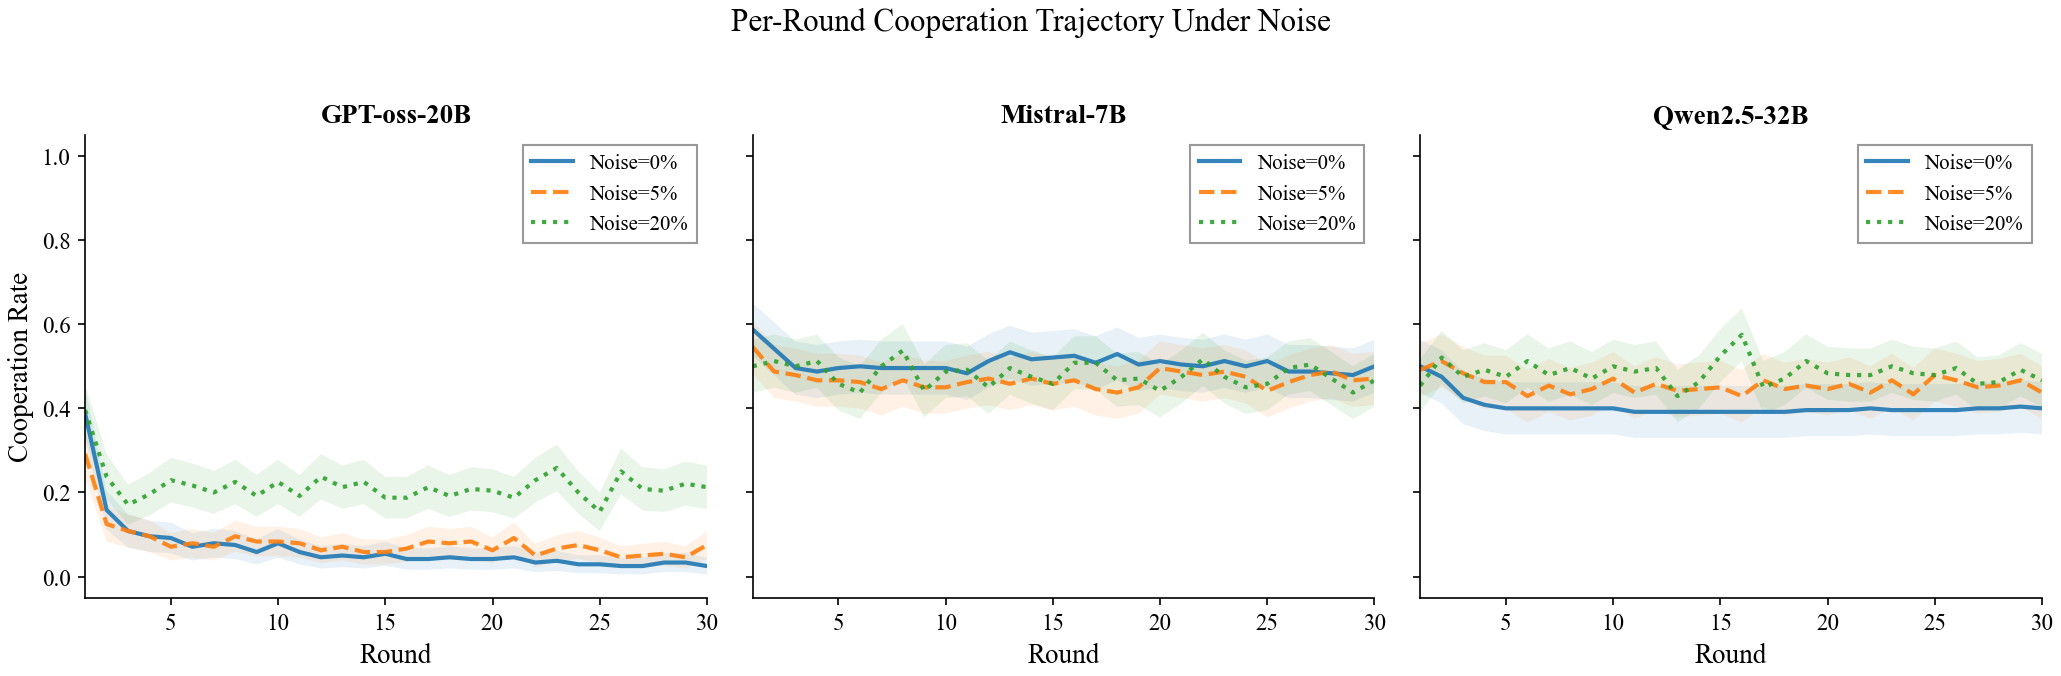

Saved: fig2d_round_trajectory_noise.pdf/png


In [8]:
# ── Figure 2d: Per-round cooperation trajectory under different noise levels ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, model in enumerate(models_order):
    ax = axes[idx]
    sub = df[df['model'] == model]
    
    for noise in noise_levels:
        noise_sub = sub[sub['agent1_noise_rate'] == noise]
        # Parse strategies and compute per-round coop rate
        all_strats = noise_sub['agent1_strategies'].apply(ast.literal_eval).tolist()
        per_round = np.array([[1 if s == 'OptionB' else 0 for s in game] for game in all_strats])
        round_means = per_round.mean(axis=0)
        round_sems = per_round.std(axis=0) / np.sqrt(len(per_round))
        
        rounds = np.arange(1, 31)
        linestyle = '-' if noise == 0.0 else '--' if noise == 0.05 else ':'
        ax.plot(rounds, round_means, linewidth=2, linestyle=linestyle,
                label=f'Noise={NOISE_LABELS[noise]}', alpha=0.9)
        ax.fill_between(rounds,
                        round_means - 1.96 * round_sems,
                        round_means + 1.96 * round_sems,
                        alpha=0.1)
    
    ax.set_xlabel('Round')
    ax.set_title(model, fontsize=13, fontweight='bold')
    ax.legend(loc='best', frameon=True, fancybox=False, edgecolor='gray', fontsize=10)
    ax.set_xlim(1, 30)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel('Cooperation Rate')
fig.suptitle('Per-Round Cooperation Trajectory Under Noise', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig2d_round_trajectory_noise.pdf')
fig.savefig(f'{FIGURE_DIR}fig2d_round_trajectory_noise.png')
plt.show()
print('Saved: fig2d_round_trajectory_noise.pdf/png')